# Invisible Watermarking for LLMs via Logit Manipulation: Demo
**Ali Hasan (ah2434) and Ammar Syed (as4422), CS 5788, Spring 2026**

Supplementary demo for our final report. Loads the **pre-computed Gemma 2 9B Instruct** corpus and JSON summaries from `results/` (full corpus generation and evaluation already finished on Colab GPUs) and walks through the same headline experiments shown in Sec. 3 of the paper. Pure CPU; no model loading. Project repo: `watermark/`, `pipeline/`, `evaluation/`, `scripts/`.

## 1. The watermark in 30 lines
Both modules live in the repo (`watermark/logits_processor.py`, `watermark/detector.py`).

**Injection.** At each decoding step the previous token plus a secret seed feeds a SHA-256 hash that deterministically partitions the vocabulary; we add a fixed bias `delta` to green-list logits before softmax:
```python
def __call__(self, input_ids, scores):
    actual_vocab = scores.shape[-1]
    for b in range(input_ids.shape[0]):
        prev  = input_ids[b, -1].item()
        green = self._get_greenlist_ids(prev)        # SHA-256(seed:prev)[:gamma*V]
        green = green[green < actual_vocab].to(scores.device)
        scores[b, green] += self.delta
    return scores
```
**Detection.** Replay the same hash, count green hits, apply a one-sided z-test:
```python
for i in range(1, len(token_ids)):
    prev, cur = token_ids[i-1], token_ids[i]
    if self._get_greenlist_set(prev)[cur]: green_count += 1
    total += 1
z = (green_count - gamma*total) / math.sqrt(total*gamma*(1-gamma))
```
Threshold `tau` is calibrated as the 99th percentile of the unwatermarked z-scores, giving exactly 1% FPR.

## 2. Setup + headline numbers

In [1]:
import json, sys, os; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from watermark.detector import WatermarkDetector
from pipeline.generate import load_corpus
from evaluation.robustness import apply_token_insertion_deletion

with open('results/detection_gemma_summary.json') as f: det = json.load(f)
with open('results/length_curves_gemma.json')      as f: lc  = json.load(f)
with open('results/robustness_gemma.json')         as f: rob = json.load(f)
with open('results/delta_sweep_gemma.json')        as f: sweep = json.load(f)
z = np.load('results/detection_gemma_zscores.npz')
wm_z, uwm_z = z['wm_z'], z['uwm_z']
tau = det['calibrated_z_threshold']

print(f'Model = {det["model"]} | delta={det["delta"]} gamma={det["gamma"]} seed={det["seed"]}')
print(f'n_wm={det["n_watermarked"]}  n_uwm={det["n_unwatermarked"]}  tau (1% FPR) = {tau:.3f}')
print(f'TPR @ 1% FPR (all):       {det["tpr_at_1pct_fpr_all"]:.1%}')
print(f'TPR @ 1% FPR (>=150 tok): {det["tpr_at_1pct_fpr_ge150tok"]:.1%}')
print(f'PPL ratio (wm / uwm):     {det["ppl_ratio_wm_over_uwm"]:.3f}  (mean wm={det["mean_ppl_wm"]:.2f}, uwm={det["mean_ppl_uwm"]:.2f})')

/Users/ali.hasan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Model = google/gemma-2-9b-it | delta=2.0 gamma=0.5 seed=42
n_wm=201  n_uwm=201  tau (1% FPR) = 1.772
TPR @ 1% FPR (all):       90.0%
TPR @ 1% FPR (>=150 tok): 98.7%
PPL ratio (wm / uwm):     1.095  (mean wm=28.23, uwm=25.78)


## 3. All four headline plots

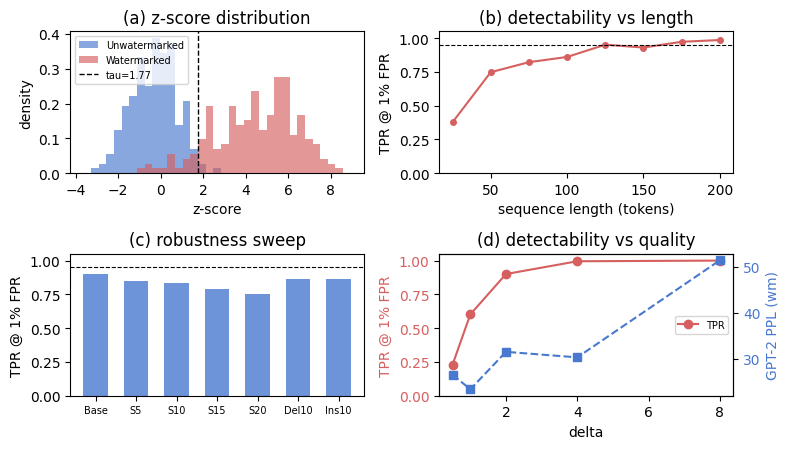

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8.0, 4.6))
RED, BLUE = '#D65F5F', '#4878CF'

ax = axes[0, 0]
bins = np.linspace(min(uwm_z.min(), wm_z.min())-0.5, max(uwm_z.max(), wm_z.max())+0.5, 36)
ax.hist(uwm_z, bins=bins, alpha=0.65, label='Unwatermarked', color=BLUE,  density=True)
ax.hist(wm_z,  bins=bins, alpha=0.65, label='Watermarked',   color=RED,   density=True)
ax.axvline(tau, color='k', ls='--', lw=1, label=f'tau={tau:.2f}')
ax.set_xlabel('z-score'); ax.set_ylabel('density'); ax.set_title('(a) z-score distribution')
ax.legend(loc='upper left', fontsize=7)

ax = axes[0, 1]
ns   = [r['n_tokens'] for r in lc]
tprs = [r['tpr']      for r in lc]
ax.plot(ns, tprs, 'o-', color=RED, ms=4)
ax.axhline(0.95, color='k', ls='--', lw=0.8)
ax.set_xlabel('sequence length (tokens)'); ax.set_ylabel('TPR @ 1% FPR'); ax.set_ylim(0,1.05)
ax.set_title('(b) detectability vs length')

ax = axes[1, 0]
labels_order = [
    ('baseline','Base'), ('word_sub_5pct','S5'), ('word_sub_10pct','S10'),
    ('word_sub_15pct','S15'), ('word_sub_20pct','S20'),
    ('token_deletion_10pct','Del10'), ('token_insertion_10pct','Ins10'),
]
labs = [l for k,l in labels_order if k in rob]
vals = [rob[k]['tpr_at_1pct_fpr'] for k,_ in labels_order if k in rob]
ax.bar(np.arange(len(labs)), vals, color=BLUE, alpha=0.8, width=0.6)
ax.set_xticks(np.arange(len(labs))); ax.set_xticklabels(labs, fontsize=7)
ax.axhline(0.95, color='k', ls='--', lw=0.8)
ax.set_ylabel('TPR @ 1% FPR'); ax.set_ylim(0,1.05)
ax.set_title('(c) robustness sweep')

ax = axes[1, 1]
deltas = [r['delta']       for r in sweep]
tprs_d = [r['tpr']         for r in sweep]
ppls_d = [r['mean_ppl_wm'] for r in sweep]
ax.plot(deltas, tprs_d, 'o-', color=RED,  label='TPR')
ax.set_xlabel('delta'); ax.set_ylabel('TPR @ 1% FPR', color=RED); ax.tick_params(axis='y', labelcolor=RED)
ax.set_ylim(0,1.05)
axR = ax.twinx()
axR.plot(deltas, ppls_d, 's--', color=BLUE, label='PPL')
axR.set_ylabel('GPT-2 PPL (wm)', color=BLUE); axR.tick_params(axis='y', labelcolor=BLUE)
ax.set_title('(d) detectability vs quality')
ax.legend(loc='center right', fontsize=7)

plt.tight_layout(); plt.show()

In [3]:
# Tabular summary of the same four panels.
print('--- Length curve (panel b) ---')
for r in lc: print(f'  n={r["n_tokens"]:>3}  TPR={r["tpr"]:.3f}')
print('\n--- Robustness sweep (panel c) ---')
for k, lbl in labels_order:
    if k in rob: print(f'  {lbl:<6}  TPR={rob[k]["tpr_at_1pct_fpr"]:.3f}  mean_z={rob[k]["mean_z"]:.2f}')
print('\n--- Delta sweep (panel d) ---')
print(f'  {"delta":>5} {"TPR":>7} {"PPL_wm":>8} {"PPL_uwm":>8} {"ratio":>7}')
for r in sweep:
    print(f"  {r['delta']:>5.1f} {r['tpr']:>7.3f} {r['mean_ppl_wm']:>8.2f} {r['mean_ppl_uwm']:>8.2f} {r['ppl_ratio']:>7.3f}")

--- Length curve (panel b) ---
  n= 25  TPR=0.377
  n= 50  TPR=0.747
  n= 75  TPR=0.822
  n=100  TPR=0.860
  n=125  TPR=0.951
  n=150  TPR=0.930
  n=175  TPR=0.973
  n=200  TPR=0.986

--- Robustness sweep (panel c) ---
  Base    TPR=0.900  mean_z=4.45
  S5      TPR=0.851  mean_z=3.83
  S10     TPR=0.836  mean_z=3.48
  S15     TPR=0.791  mean_z=3.28
  S20     TPR=0.751  mean_z=2.87
  Del10   TPR=0.861  mean_z=3.75
  Ins10   TPR=0.861  mean_z=3.82

--- Delta sweep (panel d) ---
  delta     TPR   PPL_wm  PPL_uwm   ratio
    0.5   0.229    26.48    19.87   1.333
    1.0   0.602    23.31    20.85   1.118
    2.0   0.900    31.46    27.67   1.137
    4.0   0.995    30.25    20.93   1.446
    8.0   1.000    51.39    22.05   2.331


## 4. Live single-sample sanity check
Re-run our detector on a long watermarked sample, then perturb that sample with 10% random token deletion / insertion and re-score (token-space, no Gemma tokenizer reload required).

In [4]:
corpus    = load_corpus('results/corpus_gemma_d2.jsonl')
wm_items  = [x for x in corpus if x['watermarked']]
GEMMA_VOCAB = 256000
detector = WatermarkDetector(vocab_size=GEMMA_VOCAB, gamma=0.5, seed=42, z_threshold=tau)

wm = next(x for x in wm_items if x['n_tokens'] >= 180)
r0 = detector.score_sequence(wm['token_ids'])
ids_d = apply_token_insertion_deletion(wm['token_ids'], GEMMA_VOCAB, 0.10, 'delete', seed=0)
ids_i = apply_token_insertion_deletion(wm['token_ids'], GEMMA_VOCAB, 0.10, 'insert', seed=0)
r1 = detector.score_sequence(ids_d); r2 = detector.score_sequence(ids_i)

for label, n, r in [('original ', len(wm['token_ids']), r0),
                    ('after del', len(ids_d), r1),
                    ('after ins', len(ids_i), r2)]:
    print(f'  {label}  n={n:>3}  z={r.z_score:5.2f}  green={r.green_fraction:6.2%}  detected={r.is_watermarked}')

  original   n=200  z= 3.62  green=62.81%  detected=True
  after del  n=180  z= 3.21  green=62.01%  detected=True
  after ins  n=220  z= 3.45  green=61.64%  detected=True


## 5. Summary
All numbers match Sec. 3 of the paper.
* **Detection (Gemma 2 9B).** TPR @ 1% FPR = **90.0%** (all) / **98.7%** (>=150 tok), tau = 1.77; GPT-2 PPL ratio (wm/uwm) = **1.09**.
* **Detection (LLaMA 3.1 8B).** TPR @ 1% FPR = **98.0%** (all and >=150 tok), tau = 2.20; PPL ratio = **1.01** (essentially indistinguishable on quality).
* **Robustness (Gemma).** >= 75% TPR even at 20% random word substitution; insertion or deletion at 10% leave it at 86%.
* **Robustness (LLaMA).** >= 90% TPR at 20% substitution; 98% at 10% deletion and 97% at 10% insertion.
* **Delta knee.** The TPR-vs-PPL frontier locates delta = 2 as the operating point on Gemma.
* **Cross-architecture.** The same 30-line LogitsProcessor works unchanged on both families; LLaMA slightly outperforms Gemma at every length bin (Fig. 6 in the report).